# 04 — Evaluation

Load the best fine-tuned model, predict on the held-out test set, compute final metrics, plot confusion matrix, do error analysis.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding
from src import config as C, model as M, viz, evaluate as E

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Point this at the run you want to evaluate (quick_run or fold_0/1/...)
RUN_DIR = C.MODELS_DIR / 'quick_run'

tokenizer = M.get_tokenizer()
from transformers import AutoModelForSequenceClassification
# HF Trainer saves checkpoints in subdirs; pick the latest checkpoint folder
ckpts = sorted([p for p in RUN_DIR.glob('checkpoint-*')])
ckpt = ckpts[-1] if ckpts else RUN_DIR
print(f'Loading model from: {ckpt}')
trained_model = AutoModelForSequenceClassification.from_pretrained(str(ckpt))

Loading model from: /Users/emrecanulu/Documents/Media Bias Application/Project 1: BABE Baseline/models/quick_run/checkpoint-564


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2084.37it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


In [3]:
test_df = pd.read_parquet(C.DATA_PROCESSED / 'holdout_test.parquet')
print(f'Test set: {len(test_df)} rows')

Test set: 468 rows


In [4]:
args = TrainingArguments(output_dir=str(C.MODELS_DIR / '_eval_tmp'), per_device_eval_batch_size=C.EVAL_BATCH_SIZE, report_to='none')
trainer = Trainer(model=trained_model, args=args, processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer), compute_metrics=E.compute_metrics)
preds, labels = E.predict_dataframe(trainer, test_df)
metrics = E.compute_metrics((trainer.predict(M.tokenize_dataframe(test_df, tokenizer)).predictions, labels))
print(metrics)

Map: 100%|██████████| 468/468 [00:00<00:00, 12917.87 examples/s]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Map: 100%|██████████| 468/468 [00:00<00:00, 41453.22 examples/s]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'accuracy': 0.8717948717948718, 'f1_macro': 0.8704318936877076, 'f1_biased': 0.8837209302325582, 'precision_macro': 0.8695940347970175, 'recall_macro': 0.8715642178910545}


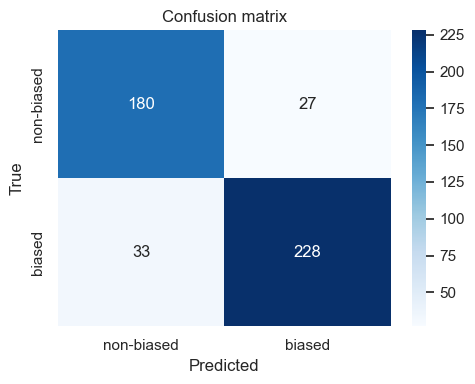

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
viz.plot_confusion(labels, preds, ax=ax)
plt.tight_layout()
plt.savefig(C.RESULTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

In [6]:
wrong = E.error_analysis(test_df, preds, labels, n=20)
wrong.to_csv(C.RESULTS_DIR / 'errors.csv', index=False)
wrong

,text,label,pred
3,Pro-democracy dissidents in Cuba condemned the...,1,0
5,On Sunday nights and early Monday mornings the...,1,0
10,"In a Friday interview with PBS, Sanders was mo...",1,0
39,The report is an in-depth analysis of the Park...,0,1
64,Veteran conservative columnist and former Nanc...,1,0
66,Surprisingly retained by Australians in a nati...,0,1
70,"Ever since, Sanders has portrayed himself as a...",0,1
76,The 2010s saw the U.S. economy achieve its lon...,1,0
89,"Meanwhile, Americans and foreigners scrambled ...",0,1
94,Germany tries to stop Trump from luring away f...,0,1


In [7]:
import json
with open(C.RESULTS_DIR / 'final_test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved.')

Saved.


Next: open `05_final_report.ipynb`.